# Antiderivative Operator - Unaligned Dataset

This tutorial demonstrates the use of learning neural operators for a data driven use case (non-physics informed). We use the DeepONets available in the `dde.nn` library. Here, we use `dde.nn.DeepONet` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

### References
[1] [Antiderivative operator from an unaligned dataset - DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_unaligned.html)

[2] [DeepXDE DeepONet PyTorch backend](https://deepxde.readthedocs.io/en/stable/_modules/deepxde/nn/pytorch/deeponet.html#)


### **Operator evaluation (paired / non-Cartesian DeepONet)**

In the standard (paired) DeepONet formulation, the branch and trunk networks are evaluated on **matched input–location pairs**. Each input function is associated with a single spatial coordinate.

The output is computed as a per-sample inner product:
$$
y_b = \sum_{p=1}^{P} \text{branch}_{b,p}\,\text{trunk}_{b,p},
$$
where:
- $ b $ indexes the sample,
- $ p $ is the shared latent dimension,
- branch and trunk features are **paired one-to-one**.

Equivalently,
$$
y_b = \mathbf{b}_b^\top \mathbf{t}_b.
$$

In code:
```python
out = torch.einsum("bp, bp -> b", b, t)
out = out.unsqueeze(1)
```

Each `b` corresponds to one input function at one spatial location. There is no spatial index `m` for this case.

### Install (Colab only)

In [1]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
from torch import nn

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
from neuromancer.callbacks import Callback
from neuromancer.modules.activations import activations

In [4]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


# Problem Setup

original source: [https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_unaligned.html](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_unaligned.html)  

We will learn the antiderivative operator 

$$G : v \mapsto u$$

defined by an ODE

$$\frac{du(x)}{dx} = v(x),\;\;x\in [0,1]$$

**Initial Condition:** 
$$u(0) = (0)$$

We learn *G* from a dataset. Each data point in the dataset is one pair of (v,u), generated as follows:

1. A random function *v* is sampled from a Gaussian random field (GRF) with the resolution m = 100.
2. Solve *u* for *v* numerically. We assume that for each *u*, we have the values of *u(x)* in only one random location *x*. 
Because for different *u*, we have the value of *u(x)* in different random locations, we call this dataset as “unaligned data”.

* Dataset information - [Source](https://yaleedu-my.sharepoint.com/:f:/g/personal/lu_lu_yale_edu/EnTn0aLimaRJuNKDOc0lfHkB2MXK8n8vAO1oV5cWVdJo3w?e=OLp80r)
    * The training dataset has size 10000.
    * The testing dataset has size 100000. (We split this into a dev/test split of size 50000 each)

* Implementation
    * Input of the branch net: the functions *v*. It is a matrix of shape (dataset size, m), e.g., (10000, 100) for the training dataset.
    * Input of the trunk net: the locations *x* of *u(x)*. It is a matrix of shape (dataset size, dimension)
        * i.e., (10000,1) for both training datasets.
    * Output: The values of *u(x)* in different locations for different *v*. It is a matrix of shape (dataset size, *1).
        * e.g., (10000, 1) for the training dataset.



## Dataset Prep

In [5]:
from urllib.request import Request, urlopen


def fetch_and_load_npz(url, split_key, data_dir=Path("data")):
    data_dir.mkdir(parents=True, exist_ok=True)
    filename = data_dir / f"antiderivative_unaligned_{split_key}.npz"

    if not filename.exists():
        print(f"Downloading {filename.name}...")
        req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urlopen(req) as resp, open(filename, "wb") as f:
            f.write(resp.read())
        print("Done.")
    else:
        print(f"Found existing file: {filename}")

    with np.load(filename, allow_pickle=True) as d:
        return {
            "X": [d[f"X_{split_key}0"], d[f"X_{split_key}1"]],
            "y": d[f"y_{split_key}"],
        }

If the URL download does not work, Download the .npz files from [here](https://yaleedu-my.sharepoint.com/:f:/g/personal/lu_lu_yale_edu/EnTn0aLimaRJuNKDOc0lfHkB2MXK8n8vAO1oV5cWVdJo3w?e=OLp80r) and move data to `examples/neural_operators/data/` 

In [6]:
data_url = "https://yaleedu-my.sharepoint.com/:f:/g/personal/lu_lu_yale_edu/EnTn0aLimaRJuNKDOc0lfHkB2MXK8n8vAO1oV5cWVdJo3w?e=OLp80r"
train_url = data_url + "%2Fantiderivative_unaligned_train.npz"
test_url = data_url + "%2Fantiderivative_unaligned_test.npz"
dataset_train = fetch_and_load_npz(train_url, "train")
dataset_test = fetch_and_load_npz(test_url, "test")

# Split the provided test set into dev (20,000) and test (rest)
dev_size = 20000
total_test = dataset_test["X"][0].shape[0]

if total_test < dev_size:
    raise ValueError(f"Requested dev_size {dev_size} > available {total_test}")


dataset_dev = {
    "X": [
        dataset_test["X"][0][:dev_size],
        dataset_test["X"][1][:dev_size],
    ],
    "y": dataset_test["y"][:dev_size],
}

dataset_test = {
    "X": [
        dataset_test["X"][0][dev_size:],
        dataset_test["X"][1][dev_size:],
    ],
    "y": dataset_test["y"][dev_size:],
}

Found existing file: data/antiderivative_unaligned_train.npz
Found existing file: data/antiderivative_unaligned_test.npz



### Dataset Structure

Each dataset split (train and test) consists of:

- **Branch input** `X[0]`: sampled input functions $ v $
- **Trunk input** `X[1]`: spatial locations $ x $
- **Output** `y`: antiderivative values $ u(x) $

The observed shapes for the training set are:

```text
X[0] : (N, m)   → N input functions, each sampled at m sensor points
X[1] : (N, 1)   → one spatial location per sample
y    : (N, 1)   → antiderivative evaluated at that location


In [7]:
print(
    "Shape of branch input:", dataset_train["X"][0].shape
)  # (dataset_size, m), input function $v$
print(
    "Shape of trunk input:", dataset_train["X"][1].shape
)  # (dataset_size, dim_x) locations $x$ for u$x$
print(
    "Shape of output:", dataset_train["y"].shape
)  # (dataset_size, dim_x), output $u(x)$ in diffeerent lcoations for different $v$

print("Shape of branch input:", dataset_test["X"][0].shape)  # (dataset_size, m)
print("Shape of trunk input:", dataset_test["X"][1].shape)  # (dataset_size, dim_x)
print("Shape of output:", dataset_test["y"].shape)  # (dataset_size, dim_x)


Shape of branch input: (10000, 100)
Shape of trunk input: (10000, 1)
Shape of output: (10000, 1)
Shape of branch input: (80000, 100)
Shape of trunk input: (80000, 1)
Shape of output: (80000, 1)


### Plotting the Input Functions $ v(x) $

Each row of the branch input `X[0]` represents a complete function $v(x)$, sampled on a uniform grid of sensor points. These functions serve as the inputs to the operator.

We visualise the first five input functions below.


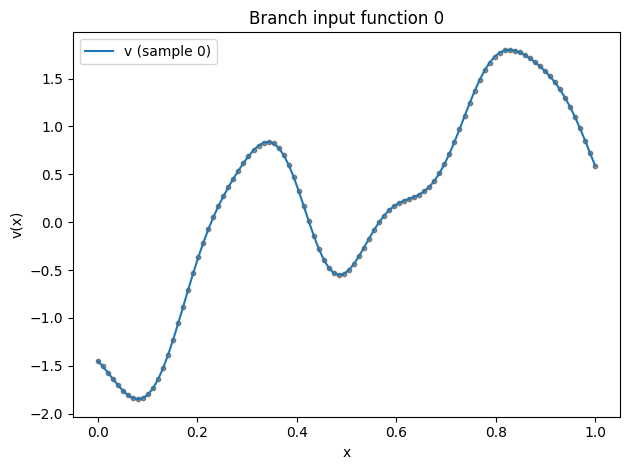

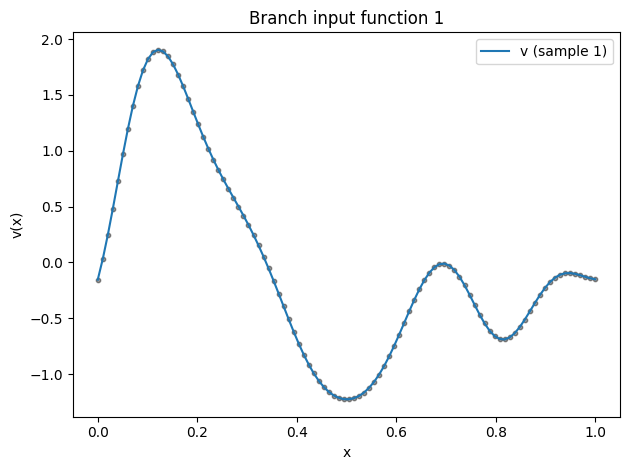

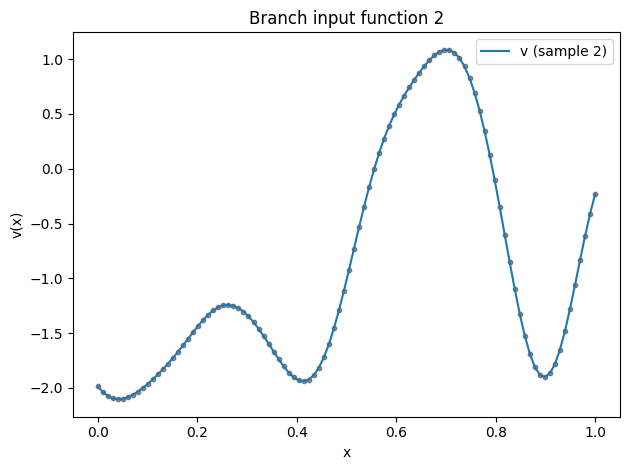

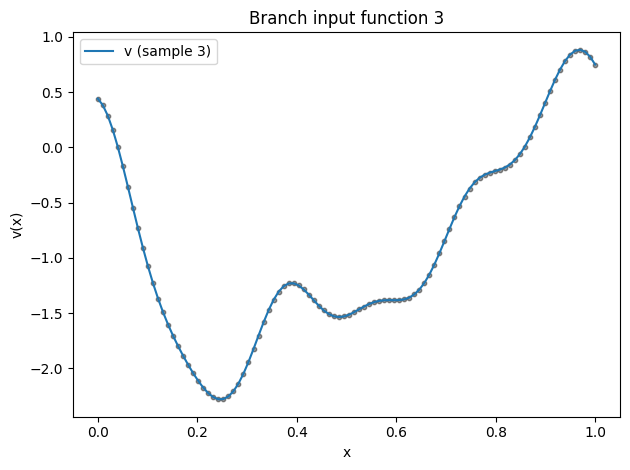

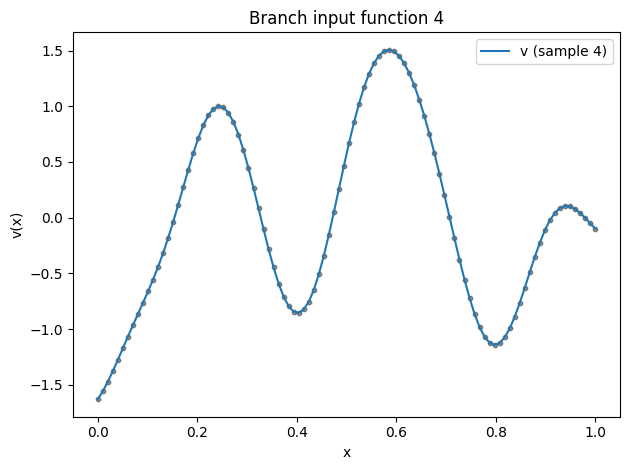

In [8]:
functions = dataset_train["X"][0]  # (10000, 100)
m = functions.shape[1]
sensors = np.linspace(0, 1, m)

num_plots = 5

for i in range(num_plots):
    plt.figure()
    plt.plot(sensors, functions[i], label=f"v (sample {i})")
    plt.scatter(sensors, functions[i], s=10, alpha=0.4, color="k")
    plt.xlabel("x")
    plt.ylabel("v(x)")
    plt.title(f"Branch input function {i}")
    plt.legend()
    plt.tight_layout()

plt.show()


### Plotting the Antiderivative Evaluations $u(x)$

The antiderivative output is provided in an **unaligned** form. Each sample consists of:

- a single spatial location $x$
- the corresponding antiderivative value $u(x)$

As a result, $u(x)$ cannot be plotted as a continuous curve for any given input function. Each input function contributes only **one** antiderivative evaluation at **one** location. The dataset therefore represents a collection of pointwise samples rather than full antiderivative trajectories.

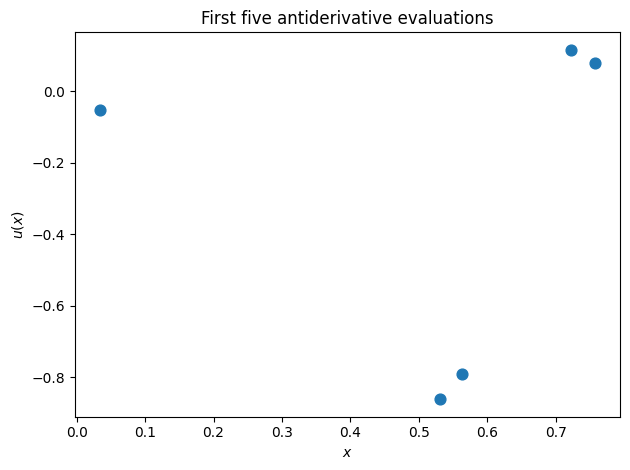

In [9]:
x = dataset_train["X"][1].squeeze()  # shape (N,)
u = dataset_train["y"].squeeze()  # shape (N,)

plt.figure()
plt.scatter(x[:5], u[:5], s=60)
plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("First five antiderivative evaluations")
plt.tight_layout()
plt.show()


### Create named dictionary datasets

In [ ]:
from neuromancer.dataset import DictDataset


def prepare_data(dataset, name):
    branch_inputs = torch.from_numpy(dataset["X"][0]).float()  # (Nsamples, m)
    trunk_inputs = torch.from_numpy(dataset["X"][1]).float()  # (Nsamples, 1)
    outputs = torch.from_numpy(dataset["y"]).float()  # (Nsamples, 1)

    print(
        f"{name} dataset: samples = {branch_inputs.shape[0]}, sensors = {branch_inputs.shape[1]}"
    )

    return DictDataset(
        {
            "branch_inputs": branch_inputs,  # (Nsamples, m)
            "trunk_inputs": trunk_inputs,  # (Nsamples, 1)
            "outputs": outputs,  # (Nsamples, 1)
        },
        name=name,
    )


train_datadict = prepare_data(dataset_train, "train")
dev_datadict = prepare_data(dataset_dev, "dev")
test_datadict = prepare_data(dataset_test, "test")

# check dimensions
print("Dimensions check:")
print("branch_inputs:", train_datadict.datadict["branch_inputs"].shape)
print("outputs:", train_datadict.datadict["outputs"].shape)
print("trunk_inputs:", train_datadict.datadict["trunk_inputs"].shape)

### Create torch DataLoaders for the Trainer

In [14]:
batch_size = 5000
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)
dev_loader = torch.utils.data.DataLoader(
    dev_datadict,
    batch_size=batch_size,
    collate_fn=dev_datadict.collate_fn,
    shuffle=False,
)
test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 5000


## Define DeepONet

The branch net is chosen as a fully connected neural network of size `[m, 40, 40]`, and the the trunk net is a fully connected neural network of size `[dim_x, 40, 40]`, where `dim_x` is diemnsion i.e. 1.

We use `dde.nn.DeepONet` to create the DeepONet directly for DeepXDE library

In [15]:
dim_x = 1  # dimension of the input x to the trunk net
dde_DeepOnet = dde.nn.DeepONet(
    [m, 40, 40],
    [dim_x, 40, 40],
    "relu",
    "Glorot normal",
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [ ]:
from neuromancer.system import Node
from neuromancer.modules.operators import DeepXDEWrapper

dde_DeepOnet_wrapped = DeepXDEWrapper(
    model=dde_DeepOnet,
    is_cartesian=False,
)

node_dde_deeponet = Node(
    dde_DeepOnet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_DeepOnet",
)
print(node_dde_deeponet)


dde_DeepOnet(branch_inputs, trunk_inputs) -> g


## Objective and Constraints in NeuroMANCER

We use Mean Squared Error(MSE) for our loss function

$$\sum_{i=1}^{D}(x_i-y_i)^2$$



In [17]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

var_y_est = variable("g")
var_y_true = variable("outputs")

nodes = [node_dde_deeponet]

# var_loss = (var_y_est == var_y_true.T) ^ 2 # this line caused issue, dont need to transpose with return_transposed=True
var_loss = (var_y_est == var_y_true) ^ 2
var_loss.name = "residual_loss"
objectives = [var_loss]

loss = PenaltyLoss(objectives, constraints=[])

problem = Problem(nodes, loss=loss, grad_inference=True)


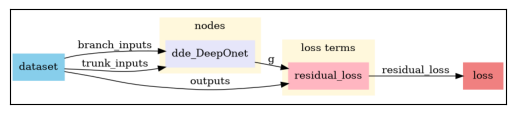

In [ ]:
# problem.show()

## Problem Solution in NeuroMANCER

In [19]:
lr = 0.001  # step size for gradient descent
epochs = 200  # number of training epochs
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 100  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.AdamW(problem.parameters(), lr=lr)

### Construct Trainer and solve the problem
The problem is slower to train compared to the `dde.nn.DeepONetCartesianProd` in `examples/neural_operators/Part_1_antiderivative_aligned.ipynb`. Vary the epochs according to your resources

In [20]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)

# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    dev_data=dev_loader,
    test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="dev_loss",
    warmup=warmup,
    device=device,
)

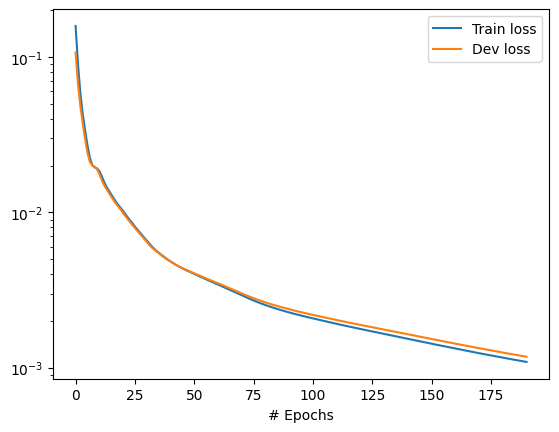

CPU times: user 1min 33s, sys: 1.07 s, total: 1min 34s
Wall time: 1min 35s


In [21]:
%%time
best_model = trainer.train()

In [22]:
# load best trained model
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [23]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
print(f"len(dev_loss_history): {len(dev_loss_history)}")

0.0011157466
len(train_loss_history): 200
len(dev_loss_history): 200


## Plot loss history w/ mean test loss

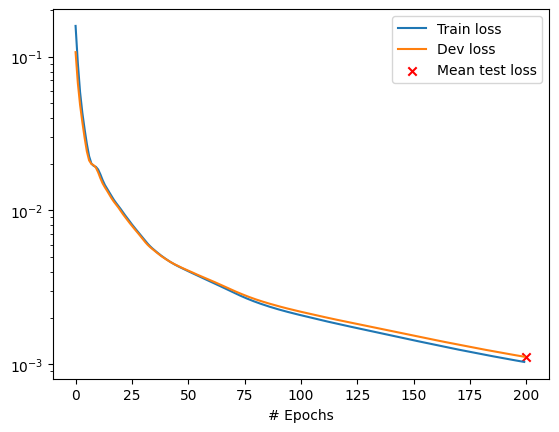

In [24]:
plt.semilogy(train_loss_history, label="Train loss")
plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results

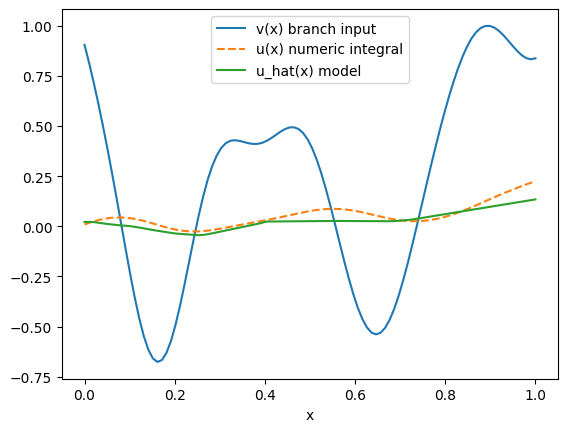

In [25]:
# Pick a test sample and build an evaluation grid
k = 211
v_sample = test_datadict.datadict["branch_inputs"][k]  # (m,)
m = v_sample.shape[0]
x_grid = torch.linspace(0, 1, steps=m).unsqueeze(1)  # (m, 1)

branch_batch = v_sample.unsqueeze(0).expand(m, -1).to(device)
trunk_batch = x_grid.to(device)

with torch.no_grad():
    preds = problem.predict(
        {"branch_inputs": branch_batch, "trunk_inputs": trunk_batch}
    )
u_pred = preds["g"].squeeze(1).cpu().numpy()  # (m,)

h = 1.0 / (m - 1)
u_true = torch.cumsum(v_sample * h, dim=0).cpu().numpy()  # (m,)
v_np = v_sample.cpu().numpy()
x_np = x_grid.squeeze(1).cpu().numpy()  # (m,)

plt.plot(x_np, v_np, label="v(x) branch input")
plt.plot(x_np, u_true, label="u(x) numeric integral", linestyle="--")
plt.plot(x_np, u_pred, label="u_hat(x) model")
plt.xlabel("x")
plt.legend()
plt.show()


## Symbolic Integral Examples

<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_767016/1615540844.py:22: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x_np, u_pred, label="$\hat{u}(x)$ model")


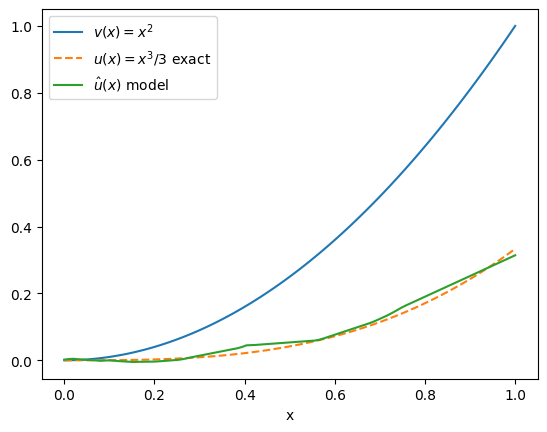

In [26]:
# Build a grid and the branch function samples on that grid
m = test_datadict.datadict["branch_inputs"].shape[1]
x_grid = torch.linspace(0, 1, steps=m).unsqueeze(1)  # (m, 1)
v_fn = torch.pow(x_grid.squeeze(1), 2).unsqueeze(0)  # (1, m)

# Repeat the branch function for each x so DeepONet sees (B=m, m) vs (B=m, 1)
branch_batch = v_fn.expand(m, -1).to(device)  # (m, m)
trunk_batch = x_grid.to(device)  # (m, 1)

with torch.no_grad():
    preds = problem.predict(
        {"branch_inputs": branch_batch, "trunk_inputs": trunk_batch}
    )
u_pred = preds["g"].view(-1).cpu().numpy()  # (m,)

x_np = x_grid.squeeze(1).cpu().numpy()
v_np = v_fn.squeeze(0).cpu().numpy()
u_true = (x_grid.squeeze(1) ** 3 / 3).cpu().numpy()  # analytic integral

plt.plot(x_np, v_np, label="$v(x) = x^2$")
plt.plot(x_np, u_true, label="$u(x) = x^3/3$ exact", linestyle="--")
plt.plot(x_np, u_pred, label="$\hat{u}(x)$ model")
plt.xlabel("x")
plt.legend()
plt.show()


<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_767016/683322439.py:18: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x_np, u_pred, label="$\hat{u}(x)$ model")


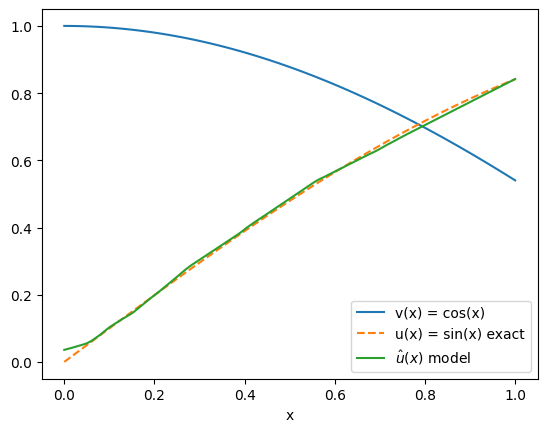

In [27]:
# Reuse the same x_grid/m from above
v_fn = torch.cos(x_grid.squeeze(1)).unsqueeze(0)  # (1, m)
branch_batch = v_fn.expand(m, -1).to(device)  # (m, m)
trunk_batch = x_grid.to(device)  # (m, 1)

with torch.no_grad():
    preds = problem.predict(
        {"branch_inputs": branch_batch, "trunk_inputs": trunk_batch}
    )
u_pred = preds["g"].view(-1).cpu().numpy()  # (m,)

x_np = x_grid.squeeze(1).cpu().numpy()
v_np = v_fn.squeeze(0).cpu().numpy()
u_true = torch.sin(x_grid.squeeze(1)).cpu().numpy()

plt.plot(x_np, v_np, label="v(x) = cos(x)")
plt.plot(x_np, u_true, label="u(x) = sin(x) exact", linestyle="--")
plt.plot(x_np, u_pred, label="$\hat{u}(x)$ model")
plt.xlabel("x")
plt.legend()
plt.show()


### Watermark

In [28]:
# %load_ext watermark
# %watermark
# %watermark --iversions